In [1]:
import copy

import numpy as np
import pandas as pd

# import torch
# import torch.nn as nn
# import torch.optim as optim
import matplotlib.pyplot as plt

import anndata as ad
import scanpy as sc
import squidpy as sq


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/envs/LCL/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/anaconda3/envs/LCL/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/opt/anaconda3/envs/LCL/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/envs/LCL/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  Fil

### Data Loading

In [2]:
data_dir = "/Users/apple/Desktop/QBS146_Bioinfo_I/final_project/dataset"
adata = ad.read_h5ad(data_dir+'/h5ad/2024_xenium_breast_tTMA1.h5ad')

In [3]:
adata.shape

(342704, 541)

In [4]:
adata.obs.columns

Index(['x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts',
       'control_codeword_counts', 'unassigned_codeword_counts',
       'deprecated_codeword_counts', 'total_counts', 'cell_area',
       'nucleus_area', 'x', 'y', 'core', 'tissue_type'],
      dtype='object')

In [5]:
print("n_cells:", adata.n_obs)
print("n_genes:", adata.n_vars)
print("n_cores:", adata.obs["core"].nunique())
print(adata.obs["tissue_type"].value_counts())

n_cells: 342704
n_genes: 541
n_cores: 145
tissue_type
OvC           51209
Tonsil        48990
CRC           45526
NSCLC         42979
BlC           39690
HNSCC         36232
BrC           23758
Melanoma      22520
Lymph node    21778
MARKER        10022
Name: count, dtype: int64


#### Top 1 cores (Core 168)

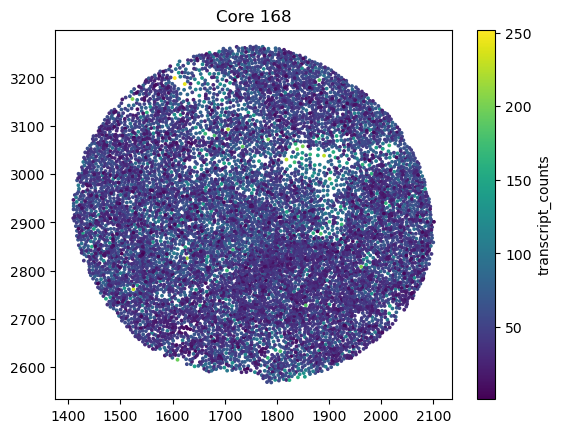

In [19]:
core_id = adata.obs["core"].value_counts().index[0]
ad = adata[adata.obs["core"] == core_id]

xy = ad.obsm["spatial"]

plt.figure()
plt.scatter(xy[:,0], xy[:,1], s=3, c=ad.obs["transcript_counts"])
plt.colorbar(label="transcript_counts")
plt.title(f"Core {core_id}")
plt.show()

In [20]:
ad

View of AnnData object with n_obs × n_vars = 9560 × 541
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'x', 'y', 'core', 'tissue_type'
    obsm: 'spatial'

#### Simulation Data

In [10]:
from sklearn.metrics.pairwise import euclidean_distances


In [53]:
def _nb2_rng(rng, mu, theta):
    """
    Negative binomial with mean=mu and dispersion=theta (NB2 parameterization).
      Var(Y) = mu + mu^2/theta
    Implemented via Gamma-Poisson mixture:
      lambda ~ Gamma(shape=theta, scale=mu/theta)
      Y ~ Poisson(lambda)
    Supports vector mu.
    """
    mu = np.asarray(mu, dtype=float)
    theta = float(theta)
    lam = rng.gamma(shape=theta, scale=mu / (theta + 1e-12))
    return rng.poisson(lam)

def simulate_svg_dataset_multipattern_nb(
    ad_core,
    n_spatial=150,
    n_null=150,
    pattern_weights=(0.4, 0.3, 0.3),   # (smooth_GP, hotspot, stripes)
    n_neighbors=15,
    lengthscale_frac=0.07,             # for smooth GP
    hotspot_sigma_frac=(0.03, 0.10),   # hotspot width range (fraction of coord span)
    stripes_period_frac=(0.10, 0.35),  # stripe period range (fraction of coord span)
    amp_range=(0.5, 1.2),              # spatial effect strength
    base_range=(0.03, 0.20),           # baseline mean
    lib_sigma=0.3,                     # library size variability
    use_real_libsize=False,            # if True, use ad_core.obs["transcript_counts"]
    theta=5.0,                        # NB dispersion (larger=less overdispersion; ->∞ ~ Poisson)
    seed=0,
):
    """
    Same as your multipattern simulator, but counts are drawn from Negative Binomial (NB2):
        Var = mu + mu^2/theta
    using a Gamma-Poisson mixture.

    Returns:
      sim: AnnData with X (counts), obsm["spatial"], var["is_spatial"], var["pattern_type"].
    """
    rng = np.random.default_rng(seed)

    coords = ad_core.obsm["spatial"].astype(float)
    n = coords.shape[0]
    if n == 0:
        raise ValueError("ad_core has 0 cells. Check core selection.")
    G = n_spatial + n_null

    # ---- library size factor ----
    if use_real_libsize and "transcript_counts" in ad_core.obs.columns:
        lib = ad_core.obs["transcript_counts"].to_numpy(dtype=float)
        lib = lib / (np.median(lib) + 1e-8)
    else:
        lib = rng.lognormal(mean=0.0, sigma=lib_sigma, size=n)

    # ---- coordinate spans ----
    x = coords[:, 0]
    y = coords[:, 1]
    span_x = np.ptp(x)
    span_y = np.ptp(y)
    span = max(span_x, span_y)

    # normalize coords to [0,1] for hotspot/stripes
    x01 = (x - x.min()) / (span_x + 1e-8)
    y01 = (y - y.min()) / (span_y + 1e-8)
    coords01 = np.c_[x01, y01]

    # ---- decide how many spatial genes of each pattern ----
    w = np.array(pattern_weights, dtype=float)
    w = w / w.sum()
    n_gp = int(round(n_spatial * w[0]))
    n_hot = int(round(n_spatial * w[1]))
    n_str = n_spatial - n_gp - n_hot

    pattern_types = (["gp"] * n_gp) + (["hotspot"] * n_hot) + (["stripes"] * n_str)
    rng.shuffle(pattern_types)

    # ---- precompute GP kernel ----
    ell = lengthscale_frac * span
    D = euclidean_distances(coords, coords)
    K = np.exp(-(D**2) / (2 * ell**2)) + 1e-6 * np.eye(n)
    L = np.linalg.cholesky(K)

    # ---- allocate ----
    base = rng.uniform(base_range[0], base_range[1], size=G)
    X = np.zeros((n, G), dtype=float)

    is_spatial = np.zeros(G, dtype=int)
    is_spatial[:n_spatial] = 1

    pat = np.array(["null"] * G, dtype=object)
    pat[:n_spatial] = pattern_types

    def zscore(v):
        return (v - v.mean()) / (v.std() + 1e-8)

    # ---- spatial genes ----
    for g in range(n_spatial):
        amp = rng.uniform(amp_range[0], amp_range[1])

        if pat[g] == "gp":
            z = zscore(L @ rng.normal(size=n))

        elif pat[g] == "hotspot":
            cx, cy = rng.uniform(0.1, 0.9, size=2)
            sigma = rng.uniform(hotspot_sigma_frac[0], hotspot_sigma_frac[1])
            r2 = (coords01[:, 0] - cx) ** 2 + (coords01[:, 1] - cy) ** 2
            z = np.exp(-r2 / (2 * sigma**2))
            if rng.random() < 0.25:
                cx2, cy2 = rng.uniform(0.1, 0.9, size=2)
                r2b = (coords01[:, 0] - cx2) ** 2 + (coords01[:, 1] - cy2) ** 2
                z = z + 0.8 * np.exp(-r2b / (2 * (0.8 * sigma) ** 2))
            z = zscore(z)

        elif pat[g] == "stripes":
            theta_ang = rng.uniform(0, np.pi)
            proj = coords01[:, 0] * np.cos(theta_ang) + coords01[:, 1] * np.sin(theta_ang)
            period = rng.uniform(stripes_period_frac[0], stripes_period_frac[1])
            phase = rng.uniform(0, 2 * np.pi)
            z = np.sin(2 * np.pi * proj / (period + 1e-8) + phase)
            if rng.random() < 0.25:
                z = np.sign(z)
            z = zscore(z)

        else:
            raise ValueError(f"Unknown pattern type: {pat[g]}")

        mu = base[g] * np.exp(amp * z) * lib
        X[:, g] = _nb2_rng(rng, mu, theta=theta)

    # ---- null genes ----
    for g in range(n_spatial, G):
        mu = base[g] * lib
        X[:, g] = _nb2_rng(rng, mu, theta=theta)

    # ---- AnnData ----
    sim = sc.AnnData(X=X)
    sim.obsm["spatial"] = coords
    sim.obs_names = ad_core.obs_names.copy()
    sim.var_names = [f"sim_g{g:03d}" for g in range(G)]
    sim.var["is_spatial"] = is_spatial
    sim.var["pattern_type"] = pat
    sim.uns["sim_theta"] = theta  # handy for reporting

    # ---- preprocess like real data ----
    sc.pp.normalize_total(sim, target_sum=1e4)
    sc.pp.log1p(sim)

    # ---- spatial neighbors (your squidpy version) ----
    sq.gr.spatial_neighbors(sim, coord_type="generic", spatial_key="spatial", n_neighs=n_neighbors)

    return sim

In [39]:

# --------------------------
# Example usage
# --------------------------
core_id = 168

# ad_core = adata[adata.obs["core"] == core_id].copy()
# sim = simulate_svg_dataset_multipattern(ad, n_spatial=150, n_null=150, seed=1)
sim = simulate_svg_dataset_multipattern_nb(ad, n_spatial=150, n_null=150, seed=1)


In [40]:
sim

AnnData object with n_obs × n_vars = 9560 × 300
    var: 'is_spatial', 'pattern_type'
    uns: 'sim_theta', 'log1p', 'spatial_neighbors'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'

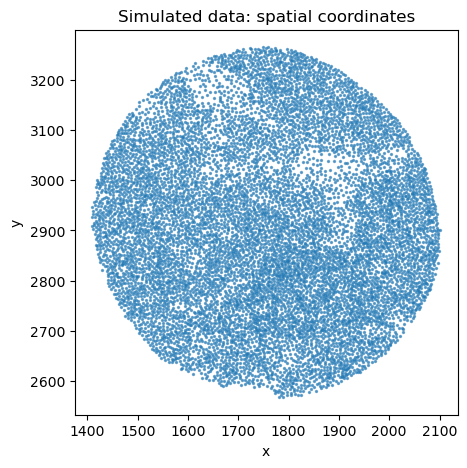

In [41]:
import matplotlib.pyplot as plt

xy = sim.obsm["spatial"]
plt.figure(figsize=(5,5))
plt.scatter(xy[:,0], xy[:,1], s=2, alpha=0.6)
plt.xlabel("x"); plt.ylabel("y")
plt.title("Simulated data: spatial coordinates")
plt.gca().set_aspect("equal", "box")
plt.show()

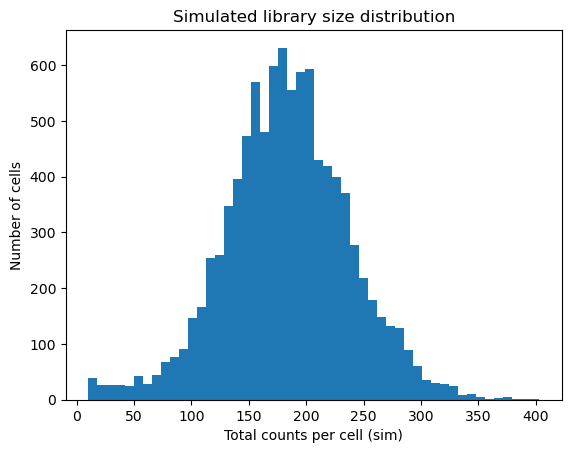

Total counts summary: [ 10.35155798 149.27794112 183.14298298 218.16225963 275.38342616
 403.19602337]


In [42]:
import numpy as np

tot = np.asarray(sim.X.sum(axis=1)).ravel()
plt.figure()
plt.hist(tot, bins=50)
plt.xlabel("Total counts per cell (sim)")
plt.ylabel("Number of cells")
plt.title("Simulated library size distribution")
plt.show()

print("Total counts summary:", np.quantile(tot, [0, 0.25, 0.5, 0.75, 0.95, 1.0]))

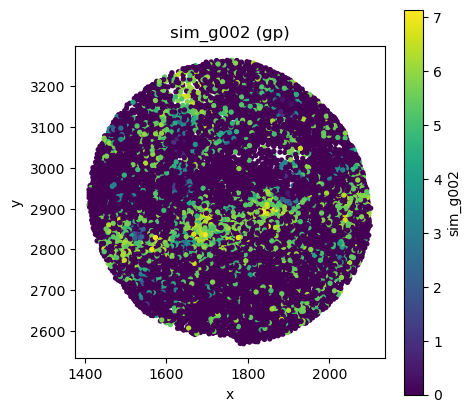

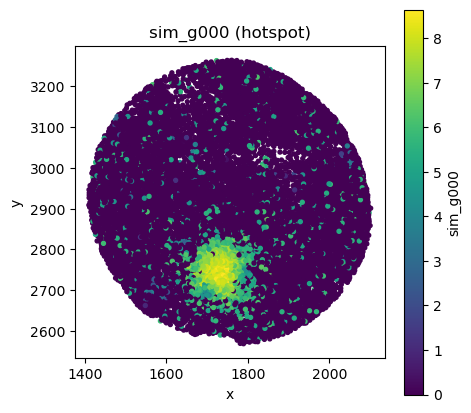

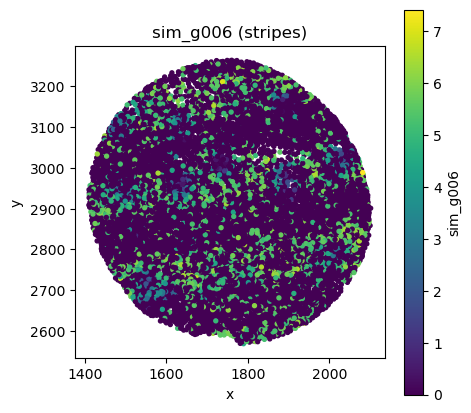

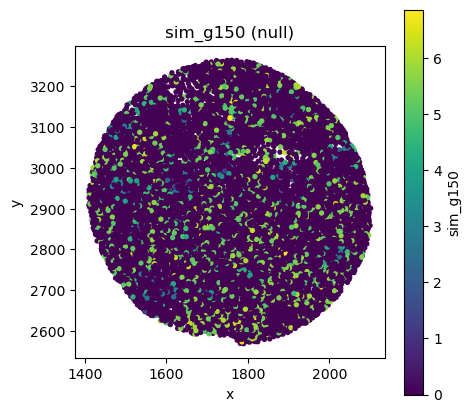

In [43]:
import numpy as np
import matplotlib.pyplot as plt

xy = sim.obsm["spatial"]

def plot_gene(sim, g, s=6):
    vals = sim[:, g].X
    vals = np.asarray(vals).ravel()
    plt.figure(figsize=(5,5))
    sca = plt.scatter(xy[:,0], xy[:,1], c=vals, s=s)
    plt.colorbar(sca, label=g)
    plt.title(f"{g} ({sim.var.loc[g,'pattern_type']})")
    plt.xlabel("x"); plt.ylabel("y")
    plt.gca().set_aspect("equal", "box")
    plt.show()

for g in genes_to_plot:
    plot_gene(sim, g, s=8)

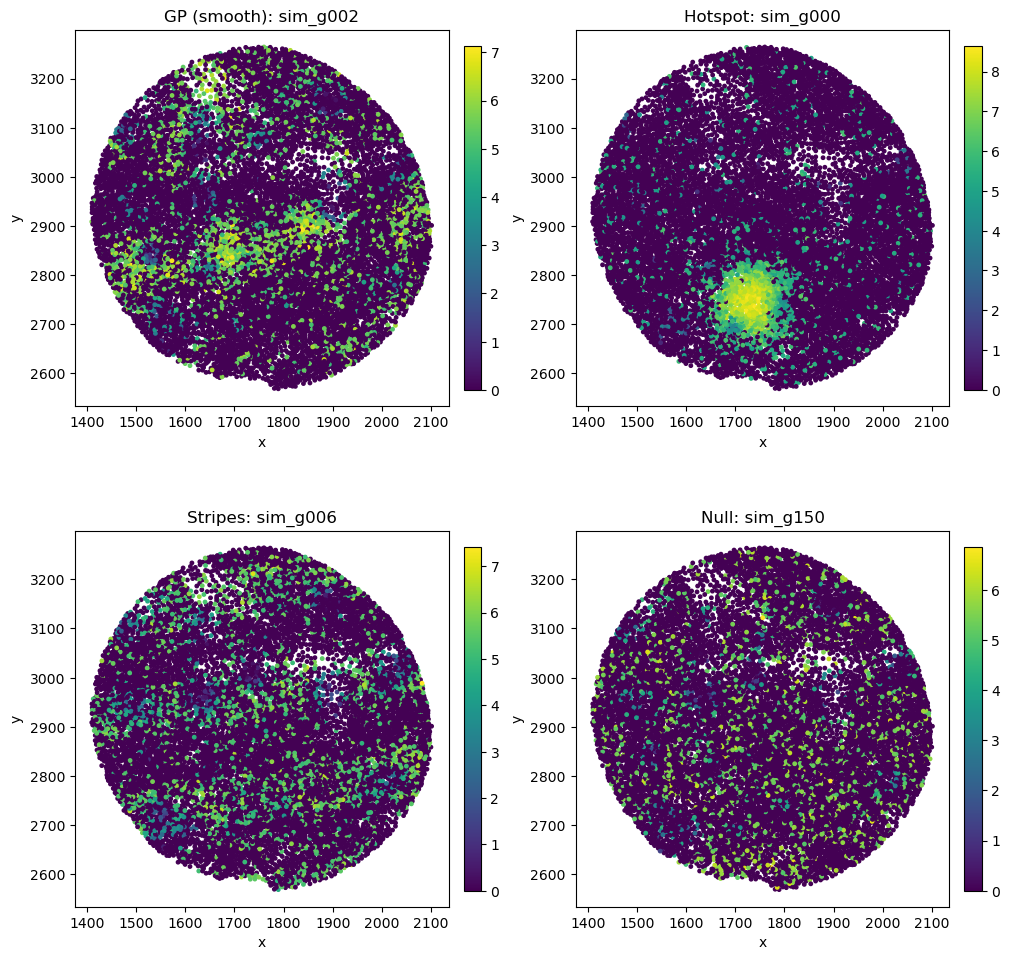

In [44]:
xy = sim.obsm["spatial"]

g_gp   = pick_one_gene("gp")
g_hot  = pick_one_gene("hotspot")
g_str  = pick_one_gene("stripes")
g_null = pick_one_gene("null")

genes  = [g_gp, g_hot, g_str, g_null]
titles = ["GP (smooth)", "Hotspot", "Stripes", "Null"]

fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)
axes = axes.ravel()

for ax, g, ttl in zip(axes, genes, titles):
    vals = np.asarray(sim[:, g].X).ravel()
    sca = ax.scatter(xy[:,0], xy[:,1], c=vals, s=6)
    ax.set_title(f"{ttl}: {g}")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_aspect("equal", "box")
    fig.colorbar(sca, ax=ax, fraction=0.046, pad=0.04)

plt.show()

In [45]:
sq.gr.spatial_autocorr(sim, mode="moran", n_perms=200)
moran = sim.uns["moranI"].copy()
moran = moran.join(sim.var[["is_spatial","pattern_type"]])

/opt/anaconda3/envs/LCL/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/envs/LCL/lib/python3.10/threading.py", line 973, in _bootstrap
    self._bootstrap_inner()
  File "/opt/anaconda3/envs/LCL/lib/python3.10/threadi

In [46]:
moran.groupby("pattern_type")["I"].median()

pattern_type
gp         0.095924
hotspot    0.363756
null       0.003903
stripes    0.053139
Name: I, dtype: float64

In [47]:
from scipy.stats import kendalltau

score = moran["I"]
truth = sim.var["is_spatial"].values

tau, p = kendalltau(score, truth)
print("Kendall tau:", tau)

Kendall tau: 0.7082882469748284


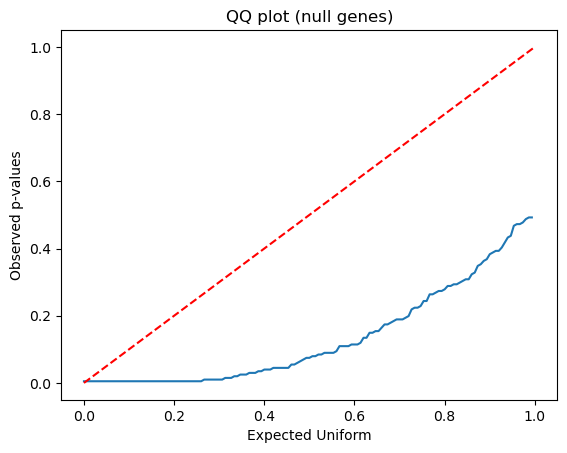

In [48]:
null_p = moran.loc[moran["pattern_type"]=="null", "pval_sim"].values
null_p = np.sort(null_p)

exp = np.linspace(0,1,len(null_p),endpoint=False)

plt.plot(exp, null_p)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("Expected Uniform")
plt.ylabel("Observed p-values")
plt.title("QQ plot (null genes)")
plt.show()

### with different difficulity

In [ ]:
scenarios = {
    "easy": dict(
        amp_range=(0.9, 1.6),
        lengthscale_frac=0.10,
        base_range=(0.05, 0.25),
        lib_sigma=0.25,
    ),
    "medium": dict(
        amp_range=(0.35, 0.9),
        lengthscale_frac=0.07,
        base_range=(0.03, 0.20),
        lib_sigma=0.30,
    ),
    "hard": dict(
        amp_range=(0.2, 0.6),
        lengthscale_frac=0.04,
        base_range=(0.01, 0.10),
        lib_sigma=0.45,
    ),
}

sims = {}
for name, params in scenarios.items():
    sims[name] = simulate_svg_dataset_multipattern_nb(
        ad,  # your core AnnData
        n_spatial=150,
        n_null=150,
        seed=1,
        **params,
    )
    print(name, sims[name].shape, sims[name].var["pattern_type"].value_counts().to_dict())

In [ ]:
from scipy.stats import kendalltau, ks_2samp
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate_moran(sim, n_perms=200):
    
    # Run Moran
    sq.gr.spatial_autocorr(sim, mode="moran", n_perms=n_perms)
    
    moran = sim.uns["moranI"].copy()
    moran = moran.join(sim.var[["is_spatial","pattern_type"]])
    
    score = moran["I"].values
    truth = moran["is_spatial"].values
    
    # Kendall
    tau, _ = kendalltau(score, truth)
    
    # AUROC
    auroc = roc_auc_score(truth, score)
    
    # AUPRC
    auprc = average_precision_score(truth, score)
    
    # KS calibration test on null p-values
    pcol = [c for c in moran.columns if "pval" in c][0]
    null_p = moran.loc[moran["pattern_type"]=="null", pcol].values
    ks_stat, _ = ks_2samp(null_p, np.random.uniform(size=len(null_p)))
    
    return {
        "kendall_tau": tau,
        "auroc": auroc,
        "auprc": auprc,
        "ks_null": ks_stat,
    }

In [51]:
results = {}

for name, sim in sims.items():
    print("Running Moran for:", name)
    results[name] = evaluate_moran(sim)

results_df = pd.DataFrame(results).T
results_df

Running Moran for: easy


/opt/anaconda3/envs/LCL/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/envs/LCL/lib/python3.10/threading.py", line 973, in _bootstrap
    self._bootstrap_inner()
  File "/opt/anaconda3/envs/LCL/lib/python3.10/threadi

Running Moran for: medium


/opt/anaconda3/envs/LCL/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/envs/LCL/lib/python3.10/threading.py", line 973, in _bootstrap
    self._bootstrap_inner()
  File "/opt/anaconda3/envs/LCL/lib/python3.10/threadi

Running Moran for: hard


/opt/anaconda3/envs/LCL/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/envs/LCL/lib/python3.10/threading.py", line 973, in _bootstrap
    self._bootstrap_inner()
  File "/opt/anaconda3/envs/LCL/lib/python3.10/threadi

,kendall_tau,auroc,auprc,ks_null
easy,0.708288,1.000000,1.000000,0.880000
medium,0.704951,0.997644,0.997830,0.580000
hard,0.539243,0.880667,0.908731,0.526667


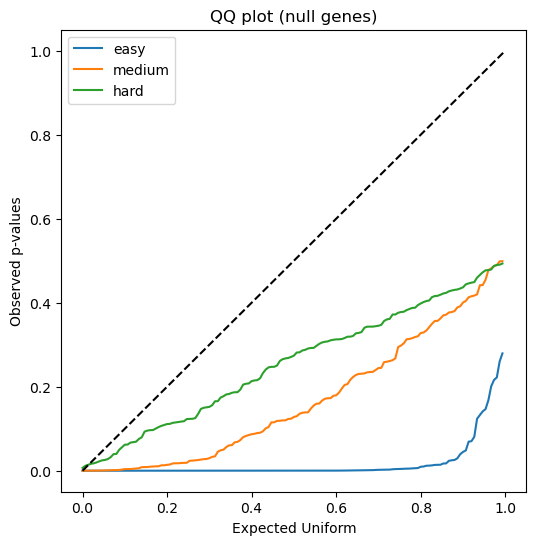

In [52]:
plt.figure(figsize=(6,6))

for name, sim in sims.items():
    moran = sim.uns["moranI"]
    pcol = [c for c in moran.columns if "pval" in c][0]
    null_p = moran.loc[sim.var["pattern_type"]=="null", pcol].values
    null_p = np.sort(null_p)
    exp = np.linspace(0,1,len(null_p),endpoint=False)
    plt.plot(exp, null_p, label=name)

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.xlabel("Expected Uniform")
plt.ylabel("Observed p-values")
plt.title("QQ plot (null genes)")
plt.show()